---
title: "Why a standard Gaussian?"
short_title: "03 · Why N(0, I)?"
subtitle: "Maximum entropy, separability, and trivial primitives — the three reasons N(0, I) is the target"
description: >
  Gaussianization maps data to N(0, I). This notebook justifies that specific
  target: the Gaussian maximises entropy at fixed covariance (rbig negentropy
  >= 0), N(0, I) factorises so total correlation vanishes after whitening, and
  its sampler, log-density, and score (-z) are all trivial — the properties
  that make it the cheap, decomposable base every flow sits on.
---

(sec-nb-03)=
# 03 — Why a standard Gaussian?

Every notebook so far has mapped data *to* a standard Gaussian $\mathcal{N}(0,
I)$ without questioning the destination. Why not a uniform, a Laplace, a
heavy-tailed base? The choice is not arbitrary — $\mathcal{N}(0, I)$ earns its
place through three properties, and each one buys Gaussianization something
concrete.

**What you will see**

- **Maximum entropy**: at a fixed mean and covariance, the Gaussian is the
  *least committal* distribution — highest differential entropy — so
  `rbig.negentropy` $\ge 0$ measures "distance from Gaussian".
- **Separability**: $\mathcal{N}(0, I) = \prod_i \mathcal{N}(0, 1)$, so once we
  reach it the coordinates are independent — `rbig.total_correlation` collapses
  to $0$.
- **Trivial primitives**: its sampler is one line, its log-density is a
  squared norm, and its score is simply $-z$.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

import rbig
from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(3)

## 1. Maximum entropy at fixed covariance

Among *all* distributions on $\mathbb{R}^d$ with a given mean and covariance
$\Sigma$, the Gaussian $\mathcal{N}(\mu, \Sigma)$ has the **largest
differential entropy** {cite}`jaynes1957,coverThomas2006`:

$$
\mathcal{N}(\mu,\Sigma) = \arg\max_{p}\, H(p)
\quad\text{s.t.}\quad \mathbb{E}_p[x]=\mu,\ \operatorname{Cov}_p[x]=\Sigma,
\qquad H(\mathcal{N}) = \tfrac12\log\big((2\pi e)^d \det\Sigma\big).
$$

In words: fixing the first two moments, the Gaussian assumes the *least* about
everything else. That makes it the honest target — Gaussianizing says "I have
captured the mean and covariance structure; what remains is structureless
noise." The gap between any distribution's entropy and the Gaussian with the
same covariance is the **negentropy** $J(p) = H(\mathcal{N}_\Sigma) - H(p) \ge
0$, with equality *iff* $p$ is Gaussian. Let's see the ordering on several
unit-variance distributions.

negentropy J = H_Gaussian - H (>= 0, zero iff Gaussian):
  Gaussian : analytic J = 0.0000,  rbig.negentropy = 0.0003 nats
  Logistic : analytic J = 0.0144,  rbig.negentropy = 0.0138 nats
  Laplace  : analytic J = 0.0724,  rbig.negentropy = 0.0735 nats
  Uniform  : analytic J = 0.1765,  rbig.negentropy = 0.1434 nats


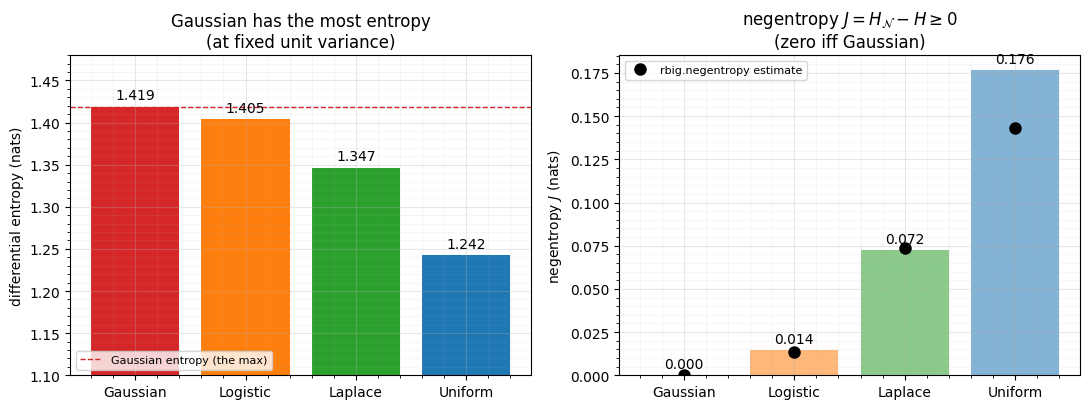

In [2]:
# Unit-variance versions of four distributions + their analytic entropies (nats).
b_lap = 1 / np.sqrt(2)                 # Laplace scale for unit variance
s_log = np.sqrt(3) / np.pi             # Logistic scale for unit variance
a_uni = np.sqrt(3)                     # Uniform half-width for unit variance
samplers = {
    "Gaussian": (lambda n: rng.standard_normal(n), 0.5 * np.log(2 * np.pi * np.e)),
    "Logistic": (lambda n: rng.logistic(0, s_log, n), np.log(s_log) + 2),
    "Laplace": (lambda n: rng.laplace(0, b_lap, n), 1 + np.log(2 * b_lap)),
    "Uniform": (lambda n: rng.uniform(-a_uni, a_uni, n), np.log(2 * a_uni)),
}

colors = ["tab:red", "tab:orange", "tab:green", "tab:blue"]
names = list(samplers)
H_analytic = np.array([samplers[k][1] for k in names])
J_analytic = H_analytic[0] - H_analytic  # negentropy vs the unit-variance Gaussian

# Corroborate the negentropy with rbig (a difference of entropies, so the
# estimator's constant bias cancels — unlike a raw entropy estimate).
J_rbig = np.array([
    float(rbig.negentropy(samplers[k][0](50_000)[:, None])[0]) for k in names
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bars = axes[0].bar(names, H_analytic, color=colors)
axes[0].axhline(H_analytic[0], color="tab:red", ls="--", lw=1,
                label="Gaussian entropy (the max)")
axes[0].bar_label(bars, fmt="%.3f", padding=3)
axes[0].set(ylabel="differential entropy (nats)", ylim=(1.1, 1.48),
            title="Gaussian has the most entropy\n(at fixed unit variance)")
axes[0].legend(loc="lower left", fontsize=8)
style_ax(axes[0])

bars = axes[1].bar(names, J_analytic, color=colors, alpha=0.55)
axes[1].plot(names, J_rbig, "ko", ms=8, label="rbig.negentropy estimate")
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(ylabel="negentropy $J$ (nats)",
            title=r"negentropy $J = H_{\mathcal{N}} - H \geq 0$"
                  "\n(zero iff Gaussian)")
axes[1].legend(loc="upper left", fontsize=8)
style_ax(axes[1])
fig.tight_layout()

print("negentropy J = H_Gaussian - H (>= 0, zero iff Gaussian):")
for k, Ja, Jr in zip(names, J_analytic, J_rbig):
    print(f"  {k:9s}: analytic J = {Ja:.4f},  rbig.negentropy = {Jr:.4f} nats")

The Gaussian bar is the tallest, and `rbig`'s estimator (black dots) tracks the
analytic values. Every other distribution has positive negentropy — a
quantitative "how non-Gaussian am I". Driving that gap to zero *is*
Gaussianization, which is why `rbig.negentropy` doubles as a convergence signal
(we use it that way in [Part 3](../)).

## 2. Separability: $\mathcal{N}(0, I) = \prod_i \mathcal{N}(0, 1)$

The *standard* Gaussian is special among Gaussians: with identity covariance it
**factorises** into independent unit-variance coordinates,

$$
\mathcal{N}(0, I) = \prod_{i=1}^d \mathcal{N}(0, 1).
$$

Independent coordinates means **zero total correlation** {cite}`watanabe1960tc`
$\mathrm{TC}(z) = \sum_i H(z_i) - H(z) = 0$ — no multi-information left. So
Gaussianization is really two jobs in one: remove dependence *and* normalise
margins. We can watch the dependence disappear: take a strongly correlated 2D
Gaussian, whiten it to $\mathcal{N}(0, I)$, and measure TC with `rbig` before
and after.

total correlation before whitening = 0.6517 nats
total correlation after  whitening = -0.0015 nats  (~0)


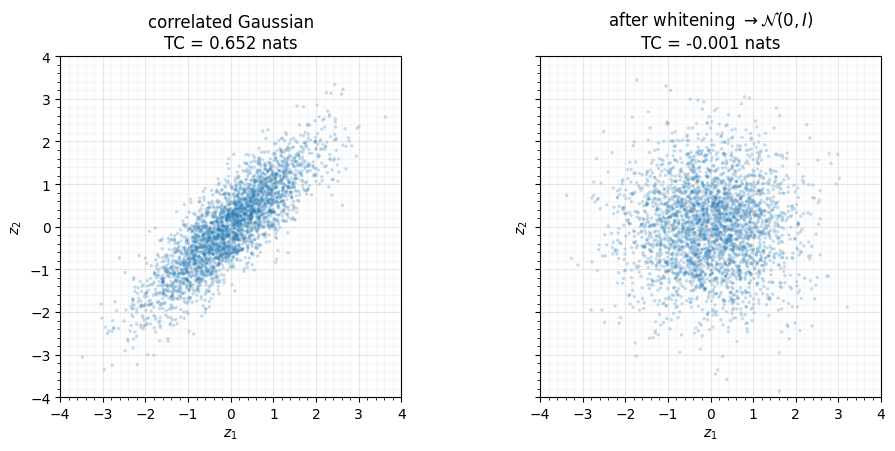

In [3]:
C = np.array([[1.0, 0.85], [0.85, 1.0]])
X = rng.standard_normal((20000, 2)) @ np.linalg.cholesky(C).T
Xw = rbig.PCARotation(whiten=True).fit(X).transform(X)

tc_before = rbig.total_correlation(X)
tc_after = rbig.total_correlation(Xw)
print(f"total correlation before whitening = {tc_before:.4f} nats")
print(f"total correlation after  whitening = {tc_after:.4f} nats  (~0)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, data, title, tc in [
    (axes[0], X, "correlated Gaussian", tc_before),
    (axes[1], Xw, r"after whitening $\to \mathcal{N}(0, I)$", tc_after),
]:
    ax.scatter(data[:3000, 0], data[:3000, 1], s=6, alpha=0.25, edgecolors="none")
    ax.set(title=f"{title}\nTC = {tc:.3f} nats", xlabel="$z_1$", ylabel="$z_2$",
           xlim=(-4, 4), ylim=(-4, 4))
    ax.set_aspect("equal")
    style_ax(ax)
fig.tight_layout()

The left cloud leans along the diagonal — knowing $z_1$ tells you a lot about
$z_2$ (TC $= 0.64$ nats). The right cloud is isotropic; the coordinates are
independent and TC has collapsed to ~0. After reaching $\mathcal{N}(0, I)$,
information-theoretic quantities **decompose per coordinate**, which is exactly
what makes Gaussianized representations so convenient for entropy and
mutual-information estimation ([Part 14](../)).

## 3. Trivial primitives

Finally, $\mathcal{N}(0, I)$ is the *computationally* easiest base a flow could
sit on. Three things every flow needs from its base are all one-liners:

- **Sampling**: $z \sim \mathcal{N}(0, I)$ is `jax.random.normal` — no MCMC, no
  rejection.
- **Log-density**: $\log p(z) = -\tfrac{d}{2}\log(2\pi) - \tfrac12\lVert z
  \rVert^2$ — just a squared norm.
- **Score**: $\nabla_z \log p(z) = -z$ — a *linear* vector field pointing at
  the origin.

The score being exactly $-z$ is worth dwelling on: it is what makes the base
trivial for score-based and diffusion methods {cite}`song2019score`
([Part 9](../)). Let's confirm it by autodiff, and read the base straight off a
`gauss_flows` flow.

z                      = [-0.12028701  1.32257788]
score grad log p(z)    = [ 0.12028701 -1.32257788]
-z                     = [ 0.12028701 -1.32257788]
score == -z ?            True


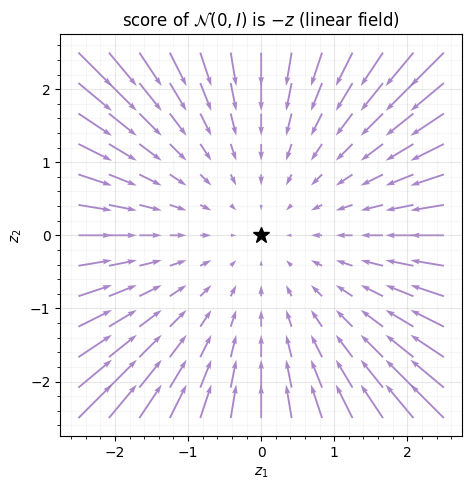

In [4]:
import gauss_flows as gf

flow = gf.gaussianization_flow(jr.key(0), n_dims=2, n_layers=4, n_components=8)
base = flow.base_dist  # the N(0, I) every Gaussianization flow targets

z = jnp.asarray(rng.standard_normal(2))
score = jax.grad(base.log_prob)(z)   # d/dz log p(z)
print(f"z                      = {np.asarray(z)}")
print(f"score grad log p(z)    = {np.asarray(score)}")
print(f"-z                     = {np.asarray(-z)}")
print(f"score == -z ?            {bool(jnp.allclose(score, -z, atol=1e-6))}")

# Visualise the score field: it points straight at the origin everywhere.
gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 13), np.linspace(-2.5, 2.5, 13))
pts = np.stack([gx.ravel(), gy.ravel()], 1)
S = jax.vmap(jax.grad(base.log_prob))(jnp.asarray(pts))
S = np.asarray(S)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.quiver(pts[:, 0], pts[:, 1], S[:, 0], S[:, 1], color="tab:purple",
          alpha=0.8, scale=30)
ax.plot(0, 0, "k*", ms=12)
ax.set(title=r"score of $\mathcal{N}(0, I)$ is $-z$ (linear field)",
       xlabel="$z_1$", ylabel="$z_2$")
ax.set_aspect("equal")
style_ax(ax)
fig.tight_layout()

Autodiff confirms $\nabla_z \log p(z) = -z$, and the quiver shows the field is a
clean linear pull toward the origin — no curvature, no surprises. Cheap
sampling, a squared-norm density, and a linear score together make
$\mathcal{N}(0, I)$ the base that keeps `flow.log_prob` and `flow.sample` cheap
in [notebook 02](02_forward_vs_inverse.ipynb).

## Recap

| property | statement | what it buys | package |
|---|---|---|---|
| max entropy | Gaussian maximises $H$ at fixed $\Sigma$ | negentropy $\ge 0$ = "non-Gaussianity" | `rbig.negentropy` |
| separability | $\mathcal{N}(0,I)=\prod_i\mathcal{N}(0,1)$ | TC $\to 0$; IT decomposes per-coord | `rbig.total_correlation` |
| trivial sampler | `jax.random.normal` | cheap generation | `flow.sample` |
| trivial density | $-\tfrac{d}{2}\log 2\pi-\tfrac12\lVert z\rVert^2$ | cheap `log_prob` base term | `flow.base_dist.log_prob` |
| trivial score | $\nabla\log p = -z$ | linear field for diffusion/score | `jax.grad(base.log_prob)` |

**Next up.** With the target justified, we name the object we have been
building. [04 — Density destructors](04_density_destructors.ipynb) introduces
the Inouye–Ravikumar framing — Gaussianization as iterated whitening plus an
elementwise nonlinearity — and the picture that ties the whole method together.